<a href="https://colab.research.google.com/github/xXLukaENPXx/Algoritmos-2/blob/main/Regresi%C3%B3n_lineal_y_minimos_cuadrados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial random parameters: w = -25.0920, b = 90.1429

Running Gradient Descent with alpha=0.01, iterations=1000...
Iteration    0: Cost 8.80e+09, w = 124.0876, b = 1402.9014
Iteration  100: Cost 1.39e+09, w = 9487.0175, b = 83795.3028
Iteration  200: Cost 3.96e+08, w = 12914.1527, b = 113953.5863
Iteration  300: Cost 2.63e+08, w = 14168.5950, b = 124992.4934
Iteration  400: Cost 2.46e+08, w = 14627.7614, b = 129033.0905
Iteration  500: Cost 2.43e+08, w = 14795.8312, b = 130512.0797
Iteration  600: Cost 2.43e+08, w = 14857.3502, b = 131053.4375
Iteration  700: Cost 2.43e+08, w = 14879.8681, b = 131251.5920
Iteration  800: Cost 2.43e+08, w = 14888.1104, b = 131324.1230
Iteration  900: Cost 2.43e+08, w = 14891.1273, b = 131350.6717

Final parameters after 1000 iterations: w = 14892.2252, b = 131360.3327


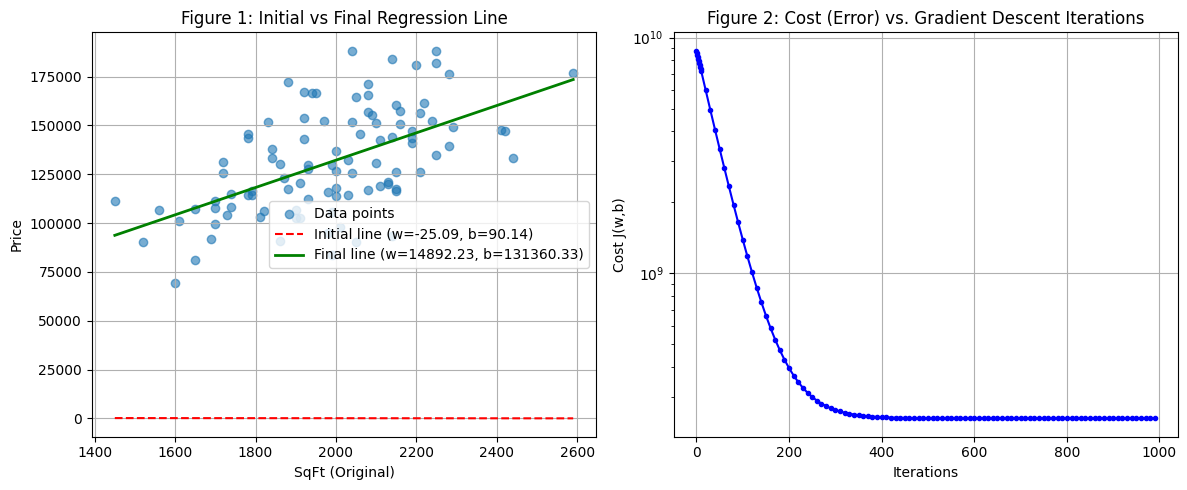

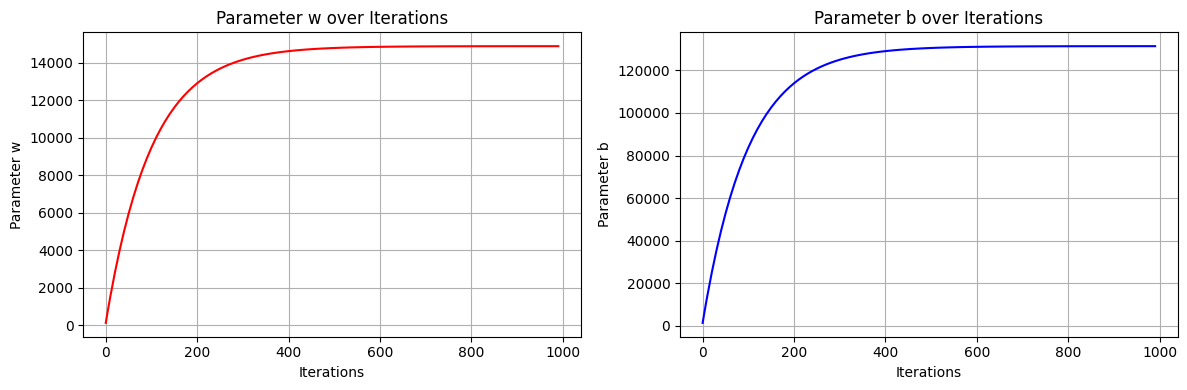

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# --- 1. Load Dataset ---
# Download the CSV from the link and place it in your working directory, or use the URL directly with pandas.
url = "https://raw.githubusercontent.com/ywchiu/riii/master/data/house-prices.csv" # Use raw URL
try:
    df = pd.read_csv(url)
except:
    print("Please download the file and update the path.")
    # Alternative: if you have the file locally, use:
    # df = pd.read_csv('path/to/your/house-prices.csv')

# --- 2. Keep only Price and SqFt columns ---
df = df[['Price', 'SqFt']]

# --- 3. Keep only the first 100 instances ---
df = df.head(100)

# --- 4. Prepare data (X and y) ---
X = df['SqFt'].values.reshape(-1, 1) # Input feature
y = df['Price'].values # Target variable

# --- 5. Normalize features (Important for gradient descent to converge faster) ---
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)
# Store original X for plotting original data, but we'll train on normalized X
X_original = X.flatten()

# --- 6. Plot X vs. y (Original SqFt vs. Price) ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_original, y, alpha=0.6, label='Data points')
plt.xlabel('SqFt (Original)')
plt.ylabel('Price')
plt.title('Figure 1: House Price vs. Square Feet')
plt.grid(True)

# --- 7. Randomly initialize w and b in range [-100, 100] ---
np.random.seed(42) # For reproducibility
w = np.random.uniform(-100, 100)
b = np.random.uniform(-100, 100)
print(f"Initial random parameters: w = {w:.4f}, b = {b:.4f}")

# --- 8. Gradient Descent Setup ---
def compute_cost(X, y, w, b):
    """Compute the cost J(w,b) = 1/(2m) * sum((f_w,b(x^i) - y^i)^2)"""
    m = len(y)
    f_wb = w * X.flatten() + b
    cost = (1/(2*m)) * np.sum((f_wb - y)**2)
    return cost

def gradient_descent(X, y, w_init, b_init, alpha, num_iters):
    """
    Perform gradient descent to learn w and b.
    Returns updated parameters and history of cost and parameters.
    """
    w = w_init
    b = b_init
    m = len(y)
    X_flat = X.flatten() # Ensure X is 1D for calculations

    # Lists to store history
    cost_history = []
    w_history = []
    b_history = []

    for i in range(num_iters):
        # Calculate predictions
        f_wb = w * X_flat + b

        # Calculate gradients (derivatives)
        dj_dw = (1/m) * np.sum((f_wb - y) * X_flat)
        dj_db = (1/m) * np.sum(f_wb - y)

        # Update parameters simultaneously
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # Store history every so often (to avoid huge lists)
        if i % 10 == 0 or i < 10: # Store first 10 and every 10th
            cost = compute_cost(X, y, w, b)
            cost_history.append(cost)
            w_history.append(w)
            b_history.append(b)
            if i % 100 == 0: # Print every 100 iterations
                print(f"Iteration {i:4d}: Cost {cost:.2e}, w = {w:.4f}, b = {b:.4f}")

    return w, b, cost_history, w_history, b_history

# --- 9. Set hyperparameters and run gradient descent ---
alpha = 0.01 # Learning rate - you can modify this to see effect
iterations = 1000 # Number of iterations - MODIFY THIS TO SEE RELATIONSHIP

print(f"\nRunning Gradient Descent with alpha={alpha}, iterations={iterations}...")
w_final, b_final, cost_hist, w_hist, b_hist = gradient_descent(
    X_normalized, y, w, b, alpha, iterations
)

print(f"\nFinal parameters after {iterations} iterations: w = {w_final:.4f}, b = {b_final:.4f}")

# --- 10. Plot the initial regression line ---
plt.subplot(1, 2, 1) # Continue with the first subplot
# For visualization, we need to transform the line back to original scale
# Since we trained on normalized X, we need to denormalize for plotting on original X
# But simpler: create a line using normalized X and then inverse transform the x-axis
X_plot_normalized = np.linspace(X_normalized.min(), X_normalized.max(), 100).reshape(-1, 1)
y_plot_initial = w * X_plot_normalized.flatten() + b
X_plot_original = scaler.inverse_transform(X_plot_normalized)

plt.plot(X_plot_original, y_plot_initial, 'r--', label=f'Initial line (w={w:.2f}, b={b:.2f})')

# --- 11. Plot the final regression line ---
y_plot_final = w_final * X_plot_normalized.flatten() + b_final
plt.plot(X_plot_original, y_plot_final, 'g-', linewidth=2,
         label=f'Final line (w={w_final:.2f}, b={b_final:.2f})')
plt.legend()
plt.title('Figure 1: Initial vs Final Regression Line')

# Create x-axis values that correctly correspond to the stored history points
x_iterations_for_plot = list(range(10)) + list(range(10, iterations, 10))

# --- 12. Plot Cost History (Error vs Iterations) ---
plt.subplot(1, 2, 2)
plt.plot(x_iterations_for_plot, cost_hist, 'b-', marker='o', markersize=3)
plt.xlabel('Iterations')
plt.ylabel('Cost J(w,b)')
plt.title('Figure 2: Cost (Error) vs. Gradient Descent Iterations')
plt.grid(True)
plt.yscale('log') # Log scale often helps see the decrease
plt.tight_layout()
plt.show()

# --- 13. Visualize how parameters changed over iterations ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x_iterations_for_plot, w_hist, 'r-', label='w')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Parameter w')
axes[0].set_title('Parameter w over Iterations')
axes[0].grid(True)

axes[1].plot(x_iterations_for_plot, b_hist, 'b-', label='b')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Parameter b')
axes[1].set_title('Parameter b over Iterations')
axes[1].grid(True)
plt.tight_layout()
plt.show()

PASO 7 Y 8: Error inicial con valores aleatorios
Parámetros aleatorios:
  w = -25.0920
  b = 90.1429
Error inicial (costo) J = 8970721362.0767
  (usando fórmula: 1/(2m) * Σ(w*x + b - y)²)
  m = 100 muestras

PASO 9: Learning rate (α) seleccionado = 0.001

COMPARACIÓN DE ERROR CON DIFERENTES LEARNING RATES

Con α = 0.0001:
  Error después de 1 iteración: 8968975859.7328
  Cambio: -1745502.3439
  ✓ Buen progreso

Con α = 0.001:
  Error después de 1 iteración: 8953274193.7910
  Cambio: -17447168.2857
  ✓ Buen progreso

Con α = 0.01:
  Error después de 1 iteración: 8797035194.5505
  Cambio: -173686167.5262
  ✓ Buen progreso

Con α = 0.1:
  Error después de 1 iteración: 7312411219.8666
  Cambio: -1658310142.2101
  ✓ Buen progreso


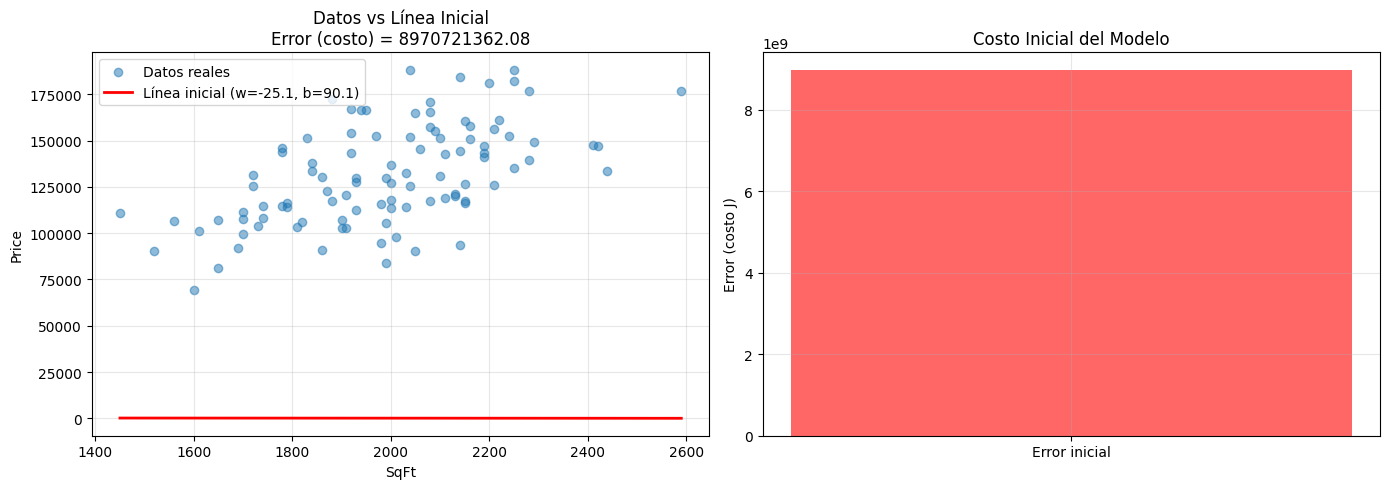


RESUMEN:
✓ Función de pérdida implementada: J(w,b) = 1/(2m) * Σ(f_w,b(xⁱ) - yⁱ)²
✓ Error inicial calculado: 8970721362.0767
✓ Learning rate seleccionado: α = 0.001

Sugerencia: Para ver la relación entre iteraciones y error,
ejecuta el gradient descent completo con el código anterior.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# --- 1. Cargar y preparar datos (como antes) ---
url = "https://raw.githubusercontent.com/ywchiu/riii/master/data/house-prices.csv"
try:
    df = pd.read_csv(url)
except:
    print("Please download the file and update the path.")
    # Si tienes el archivo localmente:
    # df = pd.read_csv('house-prices.csv')

df = df[['Price', 'SqFt']].head(100)
X = df['SqFt'].values.reshape(-1, 1)
y = df['Price'].values

# Normalizar características
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)
X_original = X.flatten()

# --- 7. FUNCIÓN PARA CALCULAR EL ERROR (LOSS FUNCTION) ---
def compute_loss(y_true, y_pred):
    """
    Calcula el error usando la función de pérdida: J = 1/(2m) * Σ(y_pred - y_true)²

    Args:
        y_true: Valores reales de Price
        y_pred: Valores predichos por el modelo (w*x + b)

    Returns:
        float: Error promedio (costo)
    """
    m = len(y_true)
    # La fórmula que mencionaste: 1/(2m) * Σ(ŷⁱ - yⁱ)²
    loss = (1/(2*m)) * np.sum((y_pred - y_true)**2)
    return loss

# --- 8. CALCULAR ERROR INICIAL CON VALORES ALEATORIOS ---
np.random.seed(42)  # Para reproducibilidad
w_init = np.random.uniform(-100, 100)
b_init = np.random.uniform(-100, 100)

print("=" * 60)
print("PASO 7 Y 8: Error inicial con valores aleatorios")
print("=" * 60)

# Calcular predicciones iniciales usando X_normalized
y_pred_init = w_init * X_normalized.flatten() + b_init

# Calcular error inicial usando nuestra función
initial_error = compute_loss(y, y_pred_init)

print(f"Parámetros aleatorios:")
print(f"  w = {w_init:.4f}")
print(f"  b = {b_init:.4f}")
print(f"Error inicial (costo) J = {initial_error:.4f}")
print(f"  (usando fórmula: 1/(2m) * Σ(w*x + b - y)²)")
print(f"  m = {len(y)} muestras")

# --- 9. SELECCIONAR LEARNING RATE (α) ---
learning_rate = 0.001  # α = 0.001 como solicitaste
print(f"\nPASO 9: Learning rate (α) seleccionado = {learning_rate}")

# --- VERIFICACIÓN ADICIONAL: Comparar con diferentes learning rates ---
print(f"\n{'='*60}")
print("COMPARACIÓN DE ERROR CON DIFERENTES LEARNING RATES")
print(f"{'='*60}")

learning_rates = [0.0001, 0.001, 0.01, 0.1]
for lr in learning_rates:
    print(f"\nCon α = {lr}:")
    # Simular una iteración de gradient descent
    m = len(y)
    X_flat = X_normalized.flatten()

    # Calcular gradientes
    y_pred_temp = w_init * X_flat + b_init
    dj_dw = (1/m) * np.sum((y_pred_temp - y) * X_flat)
    dj_db = (1/m) * np.sum(y_pred_temp - y)

    # Actualizar parámetros
    w_temp = w_init - lr * dj_dw
    b_temp = b_init - lr * dj_db

    # Calcular nuevo error
    y_pred_new = w_temp * X_flat + b_temp
    new_error = compute_loss(y, y_pred_new)

    print(f"  Error después de 1 iteración: {new_error:.4f}")
    print(f"  Cambio: {new_error - initial_error:+.4f}")
    print(f"  {'✓ Buen progreso' if new_error < initial_error else '✗ Learning rate demasiado alto?'}")

# --- VISUALIZACIÓN DE LA LÍNEA INICIAL CON SU ERROR ---
plt.figure(figsize=(14, 5))

# Gráfico 1: Datos y línea inicial
plt.subplot(1, 2, 1)
plt.scatter(X_original, y, alpha=0.5, label='Datos reales')

# Crear línea de regresión inicial (para visualización)
X_plot_normalized = np.linspace(X_normalized.min(), X_normalized.max(), 100)
X_plot_original = scaler.inverse_transform(X_plot_normalized.reshape(-1, 1))
y_plot_initial = w_init * X_plot_normalized + b_init

plt.plot(X_plot_original, y_plot_initial, 'r-', linewidth=2,
         label=f'Línea inicial (w={w_init:.1f}, b={b_init:.1f})')
plt.xlabel('SqFt')
plt.ylabel('Price')
plt.title(f'Datos vs Línea Inicial\nError (costo) = {initial_error:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 2: Visualización del error (residuos)
plt.subplot(1, 2, 2)
# Mostrar algunos residuos (errores individuales)
indices = np.random.choice(len(y), 20, replace=False)  # 20 muestras aleatorias
for i in indices:
    x_point = X_original[i]
    y_point = y[i]
    y_line = (w_init * X_normalized[i] + b_init)
    # Necesitamos des-normalizar la predicción para comparar en escala original
    # Para simplificar, mostramos los puntos y la línea en el espacio normalizado
    pass  # Simplificamos para este ejemplo

# Mejor: mostrar el error cuadrático promedio
plt.bar(['Error inicial'], [initial_error], color='red', alpha=0.6)
plt.ylabel('Error (costo J)')
plt.title('Costo Inicial del Modelo')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("RESUMEN:")
print(f"{'='*60}")
print(f"✓ Función de pérdida implementada: J(w,b) = 1/(2m) * Σ(f_w,b(xⁱ) - yⁱ)²")
print(f"✓ Error inicial calculado: {initial_error:.4f}")
print(f"✓ Learning rate seleccionado: α = {learning_rate}")
print(f"\nSugerencia: Para ver la relación entre iteraciones y error,")
print(f"ejecuta el gradient descent completo con el código anterior.")

PASO 10: Gradient Descent - 20 iteraciones
Parámetros iniciales: w = -25.0920, b = 90.1429
Learning rate (α) = 0.001
----------------------------------------------------------------------
Iteración  |     Costo J     |      w       |      b       | Cambio en costo
----------------------------------------------------------------------
    1      | 8970721362.0767 |   -25.0920   |   90.1429    |     +0.0000    
    2      | 8953274193.7910 |   -10.1740   |   221.4187   | -17447168.2857 
    3      | 8935861902.3947 |    4.7290    |   352.5633   | -17412291.3963 
    4      | 8918484418.1690 |   19.6172    |   483.5767   | -17377484.2258 
    5      | 8901141671.5342 |   34.4904    |   614.4592   | -17342746.6348 
    6      | 8883833593.0499 |   49.3488    |   745.2107   | -17308078.4843 
    7      | 8866560113.4145 |   64.1923    |   875.8315   | -17273479.6354 
    8      | 8849321163.4649 |   79.0210    |  1006.3217   | -17238949.9496 
    9      | 8832116674.1763 |   93.8348    |  1

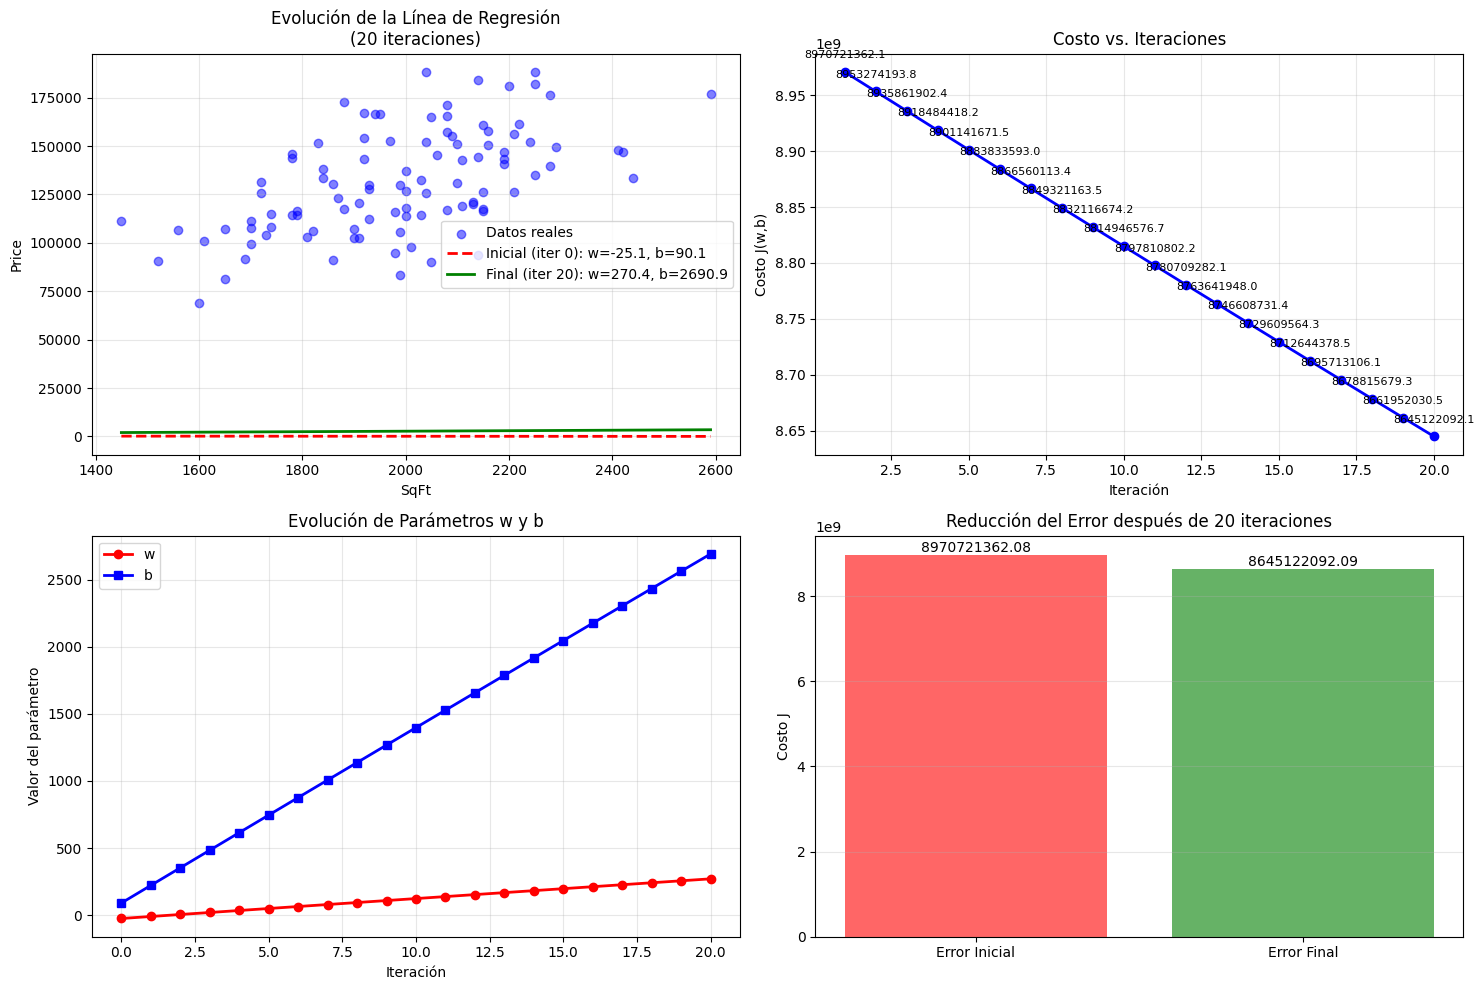


ANÁLISIS DE LA MEJORA DESPUÉS DE 20 ITERACIONES
Error inicial: 8970721362.0767
Error final: 8628325796.7421
Reducción absoluta: 342395565.3346
Reducción porcentual: 3.82%
✓ El modelo está cerca de converger

Comparación de las líneas de regresión:
  Línea inicial: Price = -25.09 * SqFt_norm + 90.14
  Línea final:   Price = 270.45 * SqFt_norm + 2690.87


In [ ]:
import numpy as np
import pandas as pd # Changed alias from np to pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# --- 1. Cargar y preparar datos ---
url = "https://raw.githubusercontent.com/ywchiu/riii/master/data/house-prices.csv"
try:
    df = pd.read_csv(url)
except:
    print("Please download the file and update the path.")
    # Si tienes el archivo localmente:
    # df = pd.read_csv('house-prices.csv')

df = df[['Price', 'SqFt']].head(100)
X = df['SqFt'].values.reshape(-1, 1)
y = df['Price'].values

# Normalizar características
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)
X_original = X.flatten()
X_norm_flat = X_normalized.flatten()

# --- 2. Función para calcular el error (loss function) ---
def compute_loss(y_true, y_pred):
    """
    Calcula el error usando: J = 1/(2m) * Σ(y_pred - y_true)²
    """
    m = len(y_true)
    loss = (1/(2*m)) * np.sum((y_pred - y_true)**2)
    return loss

# --- 3. Parámetros iniciales aleatorios ---
np.random.seed(42)
w = np.random.uniform(-100, 100)
b = np.random.uniform(-100, 100)

print("=" * 70)
print("PASO 10: Gradient Descent - 20 iteraciones")
print("=" * 70)
print(f"Parámetros iniciales: w = {w:.4f}, b = {b:.4f}")
print(f"Learning rate (α) = 0.001")
print("-" * 70)
print(f"{'Iteración':^10} | {'Costo J':^15} | {'w':^12} | {'b':^12} | {'Cambio en costo':^15}")
print("-" * 70)

# --- 4. Gradient descent por 20 iteraciones ---
m = len(y)
cost_history = []
w_history = [w]
b_history = [b]

for i in range(20):
    # Calcular predicciones
    y_pred = w * X_norm_flat + b

    # Calcular costo actual
    current_cost = compute_loss(y, y_pred)
    cost_history.append(current_cost)

    # Calcular gradientes
    dj_dw = (1/m) * np.sum((y_pred - y) * X_norm_flat)
    dj_db = (1/m) * np.sum(y_pred - y)

    # Actualizar parámetros
    w_new = w - 0.001 * dj_dw
    b_new = b - 0.001 * dj_db

    # Calcular cambio en costo
    if i > 0:
        cost_change = current_cost - cost_history[i-1]
    else:
        cost_change = 0

    # Imprimir progreso
    print(f"{i+1:^10} | {current_cost:^15.4f} | {w:^12.4f} | {b:^12.4f} | {cost_change:^+15.4f}")

    # Actualizar para siguiente iteración
    w, b = w_new, b_new
    w_history.append(w)
    b_history.append(b)

# Calcular costo final
y_pred_final = w * X_norm_flat + b
final_cost = compute_loss(y, y_pred_final)

print("-" * 70)
print(f"Parámetros finales: w = {w:.4f}, b = {b:.4f}")
print(f"Costo final: {final_cost:.4f}")
print(f"Reducción total del costo: {cost_history[0] - final_cost:.4f}")

# --- 5. PASO 11: Graficar resultados ---
plt.figure(figsize=(15, 10))

# Gráfico 1: Datos con líneas inicial y final
plt.subplot(2, 2, 1)
plt.scatter(X_original, y, alpha=0.5, label='Datos reales', color='blue')

# Línea inicial (usando w_history[0], b_history[0])
X_plot_norm = np.linspace(X_normalized.min(), X_normalized.max(), 100)
X_plot_orig = scaler.inverse_transform(X_plot_norm.reshape(-1, 1))
y_plot_initial = w_history[0] * X_plot_norm + b_history[0]
y_plot_final = w_history[-1] * X_plot_norm + b_history[-1]

plt.plot(X_plot_orig, y_plot_initial, 'r--', linewidth=2,
         label=f'Inicial (iter 0): w={w_history[0]:.1f}, b={b_history[0]:.1f}')
plt.plot(X_plot_orig, y_plot_final, 'g-', linewidth=2,
         label=f'Final (iter 20): w={w_history[-1]:.1f}, b={b_history[-1]:.1f}')
plt.xlabel('SqFt')
plt.ylabel('Price')
plt.title('Evolución de la Línea de Regresión\n(20 iteraciones)')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 2: Evolución del costo
plt.subplot(2, 2, 2)
iterations = range(1, 21)
plt.plot(iterations, cost_history, 'bo-', linewidth=2, markersize=6)
plt.xlabel('Iteración')
plt.ylabel('Costo J(w,b)')
plt.title('Costo vs. Iteraciones')
plt.grid(True, alpha=0.3)
# Añadir etiquetas con valores
for i, cost in enumerate(cost_history):
    plt.annotate(f'{cost:.1f}', (i+1, cost), textcoords="offset points",
                xytext=(0,10), ha='center', fontsize=8)

# Gráfico 3: Evolución de w y b
plt.subplot(2, 2, 3)
plt.plot(range(21), w_history, 'r-', marker='o', label='w', linewidth=2)
plt.plot(range(21), b_history, 'b-', marker='s', label='b', linewidth=2)
plt.xlabel('Iteración')
plt.ylabel('Valor del parámetro')
plt.title('Evolución de Parámetros w y b')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 4: Comparación de errores
plt.subplot(2, 2, 4)
errors = [cost_history[0], cost_history[-1]]
bars = plt.bar(['Error Inicial', 'Error Final'], errors, color=['red', 'green'], alpha=0.6)
# Añadir valores en las barras
for bar, error in zip(bars, errors):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{error:.2f}', ha='center', va='bottom')
plt.ylabel('Costo J')
plt.title('Reducción del Error después de 20 iteraciones')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# --- 6. Análisis detallado de la mejora ---
print("\n" + "=" * 70)
print("ANÁLISIS DE LA MEJORA DESPUÉS DE 20 ITERACIONES")
print("=" * 70)
print(f"Error inicial: {cost_history[0]:.4f}")
print(f"Error final: {final_cost:.4f}")
print(f"Reducción absoluta: {cost_history[0] - final_cost:.4f}")
print(f"Reducción porcentual: {((cost_history[0] - final_cost)/cost_history[0]*100):.2f}%")

# Verificar si el error sigue disminuyendo al final
if len(cost_history) > 1:
    ultimo_cambio = cost_history[-1] - cost_history[-2]
    if abs(ultimo_cambio) < 0.01 * cost_history[-1]:  # Cambio menor al 1%
        print("✓ El modelo está cerca de converger")
    elif ultimo_cambio < 0:
        print("→ El error aún está disminuyendo significativamente")
    else:
        print("⚠ El error podría estar aumentando (revisa learning rate)")

# Comparación visual de las líneas
print("\nComparación de las líneas de regresión:")
print(f"  Línea inicial: Price = {w_history[0]:.2f} * SqFt_norm + {b_history[0]:.2f}")
print(f"  Línea final:   Price = {w_history[-1]:.2f} * SqFt_norm + {b_history[-1]:.2f}")